In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import mne
from src.preprocessing.loader import load_raw
from src.preprocessing.filter import apply_filters, make_epochs
from src.analysis.features import compute_tfr

print("Imports OK")

Imports OK


In [2]:
sample_path = mne.datasets.sample.data_path()
raw_path = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"

raw = load_raw(str(raw_path))
raw = raw.copy().pick_types(eeg=True, meg=False, stim=True, eog=True)
raw = apply_filters(raw, l_freq=1.0, h_freq=40.0, notch_freq=60.0)

# Wider post-stimulus window than M6's ERP epochs: alpha suppression and
# beta rebound effects typically unfold over several hundred ms to ~1s
# after the stimulus, later than the N100/P300 window M6 focused on.
#
# tmax is pushed further out than that effect window alone would need
# (correction made during this session, 2026-07-19): a Morlet wavelet at
# n_cycles=7 needs ~2.79s of signal at the lowest analyzed frequency
# (4 Hz, at this recording's ~600.6 Hz sample rate) to avoid running off
# the edge of the epoch -- tmax=1.0 (1.3s total) was too short and raised
# "wavelet is longer than the signal". tmax=3.0 (3.3s total) gives enough
# padding for compute_tfr's lowest frequency while keeping tmin=-0.3 (and
# therefore the baseline window used in Day 2) unchanged.
epochs = make_epochs(raw, tmin=-0.3, tmax=3.0)

print(f"Total epochs: {len(epochs)}")
print(f"Conditions: {list(epochs.event_id.keys())}")

Opening raw data file C:\Users\ke725\mne_data\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...


    Read a total of 3 projection items:


        PCA-v1 (1 x 102)  idle


        PCA-v2 (1 x 102)  idle


        PCA-v3 (1 x 102)  idle


...

Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 320 events and 1983 original time points ...


0 bad epochs dropped


Total epochs: 320
Conditions: ['auditory/left', 'auditory/right', 'visual/left', 'visual/right', 'smiley', 'buttonpress']


In [3]:
# 4-39 Hz: theta through low gamma, matching config.yaml's frequency_bands
# minus delta (irrelevant here -- associated with slow-wave sleep, not
# post-stimulus response) and capped at 40 Hz to match the M2 bandpass
# filter's h_freq -- nothing above that survived filtering anyway.
freqs = np.arange(4, 40, 1)

print(f"Frequency range: {freqs[0]}-{freqs[-1]} Hz, {len(freqs)} frequencies")

Frequency range: 4-39 Hz, 36 frequencies


In [4]:
power = compute_tfr(epochs, freqs=freqs, n_cycles=7)

print(power)

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


<Average Power Estimates from Epochs (nave=320), morlet method | 59 channels × 36 freqs × 1983 times, 4.0 - 39.0 Hz, -0.30 - 3.00 s, 35.1 MiB>


In [5]:
# ITC = phase consistency across trials, not power. Called directly (not
# via compute_tfr, which hardcodes return_itc=False) to keep the two
# outputs explicit rather than a tuple that sometimes has two elements.
from mne.time_frequency import tfr_morlet

power_with_itc, itc = tfr_morlet(
    epochs, freqs=freqs, n_cycles=7, return_itc=True
)

print(itc)

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


<Inter-trial coherence from Epochs (nave=320), morlet method | 59 channels × 36 freqs × 1983 times, 4.0 - 39.0 Hz, -0.30 - 3.00 s, 35.1 MiB>


No baseline correction applied


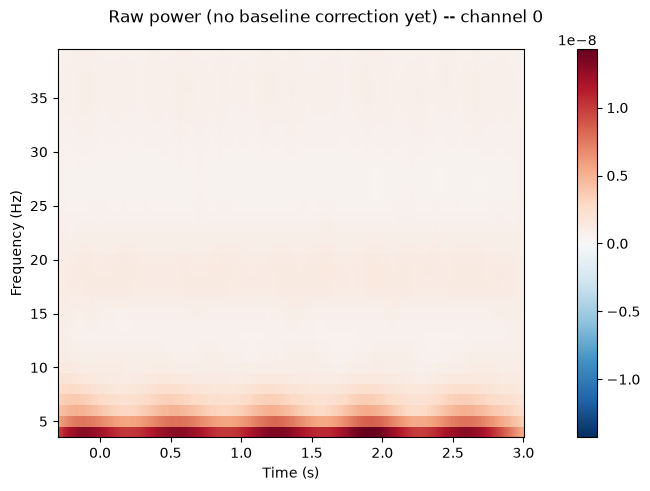

[<Figure size 640x480 with 2 Axes>]

In [6]:
# Intentionally uncorrected -- Day 2 applies logratio baseline correction;
# this raw version is what you'll compare it against.
power.plot(picks=[0], title="Raw power (no baseline correction yet) -- channel 0")